<a href="https://colab.research.google.com/github/orchid-initiative/postpartum-larc/blob/main/analysis/larc_l-and-d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
d = pandas.read_csv("/content/drive/MyDrive/Immediate Post-Partum LARC Utilization/sample aggregations/labor_and_delivery_SUMMARY_2024_20240703.csv")

In [6]:
d

,oshpd_id,hospital_name,dsch_yr,pay_cat,paycat_name,pay_plan_code,pay_plan_name,age_group,ethncty,race1,medicaid,preferred_language_not_english,known_prior_pregnancy,mental_illness,intellectual_disability,l_and_d_incl,larc,larc_uterine,larc_subcutaneous
0,150736,KERN MEDICAL CENTER,2015,2,Medi-Cal,0,0,13-19,E1,R1,1,1,0,0,0,1,0,0,0
1,150736,KERN MEDICAL CENTER,2019,2,Medi-Cal,0,0,13-19,E1,R1,1,0,0,0,0,1,0,0,0
2,150736,KERN MEDICAL CENTER,2021,2,Medi-Cal,0,0,13-19,E1,R1,1,0,0,0,0,1,0,0,0
3,150736,KERN MEDICAL CENTER,2021,2,Medi-Cal,0,0,13-19,E1,R1,1,1,0,0,0,1,0,0,0
4,150736,KERN MEDICAL CENTER,2022,2,Medi-Cal,0,0,13-19,E1,R1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21522,194219,KECK HOSPITAL OF USC,2023,2,Medi-Cal,0,0,46+,E2,R5,1,0,0,0,0,1,0,0,0
21523,194219,KECK HOSPITAL OF USC,2023,3,Private Coverage,0,0,46+,E2,R5,0,0,0,0,0,2,0,0,0
21524,194219,KECK HOSPITAL OF USC,2023,8,Self-Pay,0,0,46+,E2,R5,0,1,0,0,0,2,0,0,0
21525,194219,KECK HOSPITAL OF USC,2024,2,Medi-Cal,0,0,46+,E2,R5,1,0,0,0,0,1,0,0,0


In [7]:
def larc_stats(col):
  stat = {}
  stat_larc = {}
  for index, row in d.iterrows():
    if row[col] not in stat:
      stat[row[col]] = 0
      stat_larc[row[col]] = 0
    stat[row[col]] += row["l_and_d_incl"]
    stat_larc[row[col]] += row["larc"]
  return(stat, stat_larc)

In [8]:
race, race_larc = larc_stats("race1")

In [9]:
# racial breakdown (%)
{key: (val * 100) / sum(race.values()) for key, val in race.items()}

{'R1': 1.6700450791153603,
 'R2': 15.208906907088615,
 'R3': 6.577315221008683,
 'R4': 2.104196290805676,
 'R5': 72.41551447674946,
 'R9': 2.024022025232203}

In [10]:
# absolute larc rate by race (%)
{key: (val * 100) / sum(race.values()) for key, val in race_larc.items()}

{'R1': 0.1815266390342783,
 'R2': 1.474903942153511,
 'R3': 0.6610595104831634,
 'R4': 0.22085741082503857,
 'R5': 7.0613862584334255,
 'R9': 0.1906029709859922}

In [11]:
# relative larc rate by race (%)
{key: (val * 100) / race[key] for key, val in race_larc.items()}

{'R1': 10.869565217391305,
 'R2': 9.69763278297195,
 'R3': 10.050597976080956,
 'R4': 10.4960460100647,
 'R5': 9.751206367111612,
 'R9': 9.417040358744394}

In [12]:
# larc share by race (%)
{key: (val * 100) / sum(race_larc.values()) for key, val in race_larc.items()}

{'R1': 1.854140914709518,
 'R2': 15.064894932014834,
 'R3': 6.7521631644004945,
 'R4': 2.2558714462299134,
 'R5': 72.12608158220024,
 'R9': 1.9468479604449938}

In [13]:
ethnicity = {}
ethnicity_larc = {}
for index, row in d.iterrows():
    if row["ethncty"] not in ethnicity:
        ethnicity[row["ethncty"]] = 0
        ethnicity_larc[row["ethncty"]] = 0
    ethnicity[row["ethncty"]] += row["l_and_d_incl"]
    ethnicity_larc[row["ethncty"]] += row["larc"]
print(ethnicity)
print(ethnicity_larc)

{'E1': 25552, 'E2': 40554}
{'E1': 2456, 'E2': 4016}


In [14]:
# ethnicity breakdown (%)
{key: (val * 100) / sum(ethnicity.values()) for key, val in ethnicity.items()}

{'E1': 38.653072338365654, 'E2': 61.346927661634346}

In [15]:
# absolute larc rate by ethnicity (%)
{key: (val * 100) / sum(ethnicity.values()) for key, val in ethnicity_larc.items()}

{'E1': 3.7152452122348953, 'E2': 6.075091519680513}

In [16]:
# relative larc rate by ethnicity (%)
{key: (val * 100) / ethnicity[key] for key, val in ethnicity_larc.items()}

{'E1': 9.611772072636192, 'E2': 9.902845588597918}

In [17]:
# larc share by ethnicity (%)
{key: (val * 100) / sum(ethnicity_larc.values()) for key, val in ethnicity_larc.items()}

{'E1': 37.94808405438813, 'E2': 62.05191594561187}

In [18]:
age_group = {}
age_group_larc = {}
for index, row in d.iterrows():
    if row["age_group"] not in age_group:
        age_group[row["age_group"]] = 0
        age_group_larc[row["age_group"]] = 0
    age_group[row["age_group"]] += row["l_and_d_incl"]
    age_group_larc[row["age_group"]] += row["larc"]
print(age_group)
print(age_group_larc)

{'13-19': 11740, '20-29': 29020, '30-45': 24884, '46+': 462}
{'13-19': 1170, '20-29': 2915, '30-45': 2344, '46+': 43}


In [19]:
# age group breakdown (%)
{key: (val * 100) / sum(age_group.values()) for key, val in age_group.items()}

{'13-19': 17.759356185520225,
 '20-29': 43.8991922064563,
 '30-45': 37.642574047741505,
 '46+': 0.6988775602819713}

In [20]:
# absolute larc rate by age group (%)
{key: (val * 100) / sum(age_group.values()) for key, val in age_group_larc.items()}

{'13-19': 1.7698847305842131,
 '20-29': 4.40958460654101,
 '30-45': 3.545820349136236,
 '46+': 0.06504704565394971}

In [21]:
# relative larc rate by age group (%)
{key: (val * 100) / age_group[key] for key, val in age_group_larc.items()}

{'13-19': 9.965928449744464,
 '20-29': 10.044796691936595,
 '30-45': 9.419707442533355,
 '46+': 9.307359307359308}

In [22]:
# larc share by age group (%)
{key: (val * 100) / sum(age_group_larc.values()) for key, val in age_group_larc.items()}

{'13-19': 18.0778739184178,
 '20-29': 45.04017305315204,
 '30-45': 36.21755253399258,
 '46+': 0.6644004944375772}

In [23]:
paycat_name = {}
paycat_name_larc = {}
for index, row in d.iterrows():
    if row["paycat_name"] not in paycat_name:
        paycat_name[row["paycat_name"]] = 0
        paycat_name_larc[row["paycat_name"]] = 0
    paycat_name[row["paycat_name"]] += row["l_and_d_incl"]
    paycat_name_larc[row["paycat_name"]] += row["larc"]
print(paycat_name)
print(paycat_name_larc)

{'Medi-Cal': 20458, 'Private Coverage': 36547, 'Self-Pay': 3915, 'Medicare': 5186}
{'Medi-Cal': 2009, 'Private Coverage': 3588, 'Self-Pay': 395, 'Medicare': 480}


In [24]:
# pay category breakdown (%)
{key: (val * 100) / sum(paycat_name.values()) for key, val in paycat_name.items()}

{'Medi-Cal': 30.947266511360542,
 'Private Coverage': 55.285450639881404,
 'Self-Pay': 5.9223065984933285,
 'Medicare': 7.844976250264726}

In [25]:
# ablosute larc rate by pay category (%)
{key: (val * 100) / sum(paycat_name.values()) for key, val in paycat_name_larc.items()}

{'Medi-Cal': 3.039058481832209,
 'Private Coverage': 5.427646507124921,
 'Self-Pay': 0.597525186821166,
 'Medicare': 0.7261065561371132}

In [26]:
# relative larc rate by pay category (%)
{key: (val * 100) / paycat_name[key] for key, val in paycat_name_larc.items()}

{'Medi-Cal': 9.820119268745723,
 'Private Coverage': 9.817495280050347,
 'Self-Pay': 10.089399744572159,
 'Medicare': 9.255688391824142}

In [27]:
# larc share by pay category (%)
{key: (val * 100) / sum(paycat_name_larc.values()) for key, val in paycat_name_larc.items()}

{'Medi-Cal': 31.04140914709518,
 'Private Coverage': 55.43881334981459,
 'Self-Pay': 6.1032138442521635,
 'Medicare': 7.416563658838072}

In [28]:
d.oshpd_id.value_counts()

,count
oshpd_id,
150775,2650
150736,2348
190529,2080
191227,1879
191228,1538
194219,1522
190878,1488
190796,1433
190392,1411


In [29]:
oshpd = {}
oshpd_larc = {}
for index, row in d.iterrows():
    if row["oshpd_id"] not in oshpd:
        oshpd[row["oshpd_id"]] = 0
        oshpd_larc[row["oshpd_id"]] = 0
    oshpd[row["oshpd_id"]] += row["l_and_d_incl"]
    oshpd_larc[row["oshpd_id"]] += row["larc"]
print(oshpd)
print(oshpd_larc)

{150736: 8954, 150775: 11243, 190323: 3203, 190392: 3619, 190429: 3169, 190529: 7281, 190555: 3555, 190796: 3890, 190818: 3022, 190878: 3835, 191227: 6132, 191228: 4058, 194219: 4145}
{150736: 878, 150775: 1116, 190323: 295, 190392: 365, 190429: 304, 190529: 682, 190555: 332, 190796: 379, 190818: 293, 190878: 379, 191227: 609, 191228: 437, 194219: 403}


In [30]:
# relative larc rate by oshpd
{key: (val * 100) / oshpd[key] for key, val in oshpd_larc.items()}

{150736: 9.805673442037078,
 150775: 9.926176287467758,
 190323: 9.210115516703091,
 190392: 10.085659021829235,
 190429: 9.592931524140107,
 190529: 9.366845213569565,
 190555: 9.338959212376935,
 190796: 9.74293059125964,
 190818: 9.695565850430178,
 190878: 9.882659713168188,
 191227: 9.931506849315069,
 191228: 10.768851651059636,
 194219: 9.722557297949336}

In [31]:
d.mental_illness.value_counts()

,count
mental_illness,
0,21526
1,1


In [32]:
for index, row in d.iterrows():
    if row["mental_illness"] == 1:
        print(row)

oshpd_id                                              190818
hospital_name                     USC VERDUGO HILLS HOSPITAL
dsch_yr                                                 2023
pay_cat                                                    2
paycat_name                                         Medi-Cal
pay_plan_code                                              0
pay_plan_name                                              0
age_group                                              20-29
ethncty                                                   E1
race1                                                     R5
medicaid                                                   1
preferred_language_not_english                             0
known_prior_pregnancy                                      0
mental_illness                                             1
intellectual_disability                                    0
l_and_d_incl                                               1
larc                    

In [33]:
for index, row in d.iterrows():
    if row["intellectual_disability"] == 1:
        print(row)

In [34]:
d.intellectual_disability.value_counts()

,count
intellectual_disability,
0,21527


In [35]:
d.dsch_yr.value_counts()

,count
dsch_yr,
2023,2533
2022,2271
2021,2073
2024,1938
2020,1931
2019,1872
2018,1813
2017,1805
2016,1772


In [36]:
d.groupby(by = "dsch_yr")[["l_and_d_incl", "larc"]].sum()

,l_and_d_incl,larc
dsch_yr,,
1992,3,0
1993,1,0
1994,3,0
1995,4,0
1996,7,0
1997,14,1
1998,7,1
1999,10,0
2000,21,3


In [38]:
oshpd_larc_rates = {key: (val * 100) / oshpd[key] for key, val in oshpd_larc.items()}

<BarContainer object of 13 artists>

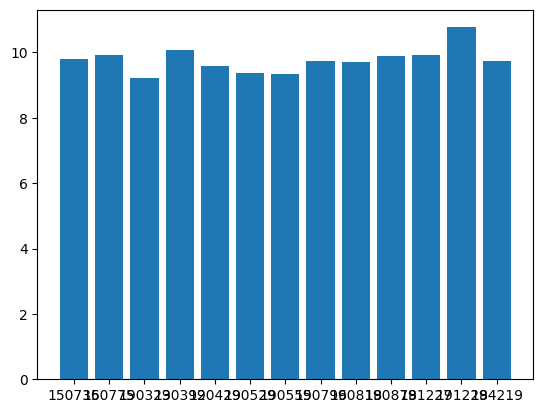

In [40]:
plt.bar([str(x) for x in oshpd_larc_rates.keys()], oshpd_larc_rates.values())